# Ramachandran Plot

This notebook provides the instructions and code to produce the corresponding figure presented in the textbook. Any figure made using Python or command-line tools will be described in a notebook like this one. These notebooks are provided so I can remember how to create these images and visualizations and speed up my work when returning to this project after a period of time. They will also provide templates for you, the student, to use should you wish to make your own version.

## Trypsin

See the notebooks for [Geis' 1974 trypsin](../01-trypsin-geis/trypsin-geis.md) structure and the [trypsin visualization example](../02-trypsin-chimera/trypsin-chimera.ipynb) for more information about trypsin.

## An Image of Trypsin

The *Py3Dmol* image of trypsin generated by the code below is similar to [Geis' 1974 trypsin](../01-trypsin-geis/trypsin-geis.md) strcture. It is a *alpha trace*, a visulation that presents the central carbon atome of each amino acid (the $\alpha$-carbon) and connects them by straight lines. This style highlights the turn and twist that occurs at each amino acid. The tortional angle for the bond coming into the $\alpha$-carbon is labeled as $\phi$ and the tortional angle for the bond coming out of the $\alpha$-carbon is labeled as $\psi$. These ideas will be presented later in this course.

The image below is an interactive *py3Dmol* widget. Use your mouse to move it around and see how the structure turns at each $\alpha$-carbon.

In [1]:
# see settings described at https://www.insilicochemistry.io/tutorials/foundations/chemistry-visualization-with-py3dmol
# see also "Visualizations/chapter01-intro/02-TrypsinVisualization/trypsin-chimera.ipynb" for more examples of py3Dmol settings

import py3Dmol

options={'backgroundColor': 'white'}

colorscheme = {'color': 'lightgray'} 

# Set up a style dictionary for cartoons.
cartoonstyle = {'arrows':False,    
                'tubes':False, 
                'style':'trace',   # or 'oval'
                'thickness': 0.2,
                'colorscheme': colorscheme}

# create the image as the object, 'view', which we can manipulate with methods
view = py3Dmol.view(query='pdb:2ptn', 
                    width=600, 
                    height=400,
                    options=options)

# Use the cartoon style for the whole structure, then add styles for specific residues later
view.setStyle({},{'cartoon': cartoonstyle,})

# add a component to show active site residues
view.addStyle(
    # Select residues 195,etc, but not backbone atoms
    {
        'model':0,'chain': 'A', 'resi':[195, 57, 102, 189], 
        'not':{'atom': ['N', 'C', 'O']}, 
    },
    # apply styles as sticks and spheres, colored by element                   
    {
        'stick': {'colorscheme': 'element', 'radius': 0.3},
        'sphere': {'colorscheme': 'element', 'scale': 0.3}
    }   
)

# show alpha carbons
view.addStyle(
    # Select atoms labelled 'CA' (alpha carbons) in chain A])
    {
        'model':0,'chain': 'A', 'atom': 'CA',
    },
    # apply styles as spheres, colored by element                   
    {
        'sphere': {'colorscheme': 'element', 'scale': 0.3}
    }
)


if True:
    view.rotate(95, 'x') # x-axis is horizontal, pointing to the right. Front rolls down
    #view.rotate(180, 'z')  # z-axis vertical, pointing up. Front rolls right
    view.rotate(180, 'y') # y-axis is is pointing out of the screen, towards the viewer. Turns counterclockwise

view.setBackgroundColor ('#f9f9f9')

view.zoomTo()
view.zoom(0.8)

view.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## A Ramachandran Plot

The $\phi$ and $\psi$ tortional angles define the change in direction of the protein backbone at each $\alpha$-carbon. What if we took the pair of $\phi$ and $\psi$ tortional angles associated with each amino acid's $\alpha$-carbon and made a plot of $\psi$ vs $\phi$? This would be the famous Ramachandran plot.

The code below will take a data set for a protein and use the tools in the *BioPython* library to extract the $\phi$ and $\psi$ tortional angles for each amino acid. I used the file [data/2PTN.cif](data/2PTN.cif) file that I obtained from the corresponding protein databank entry at [https://doi.org/10.2210/pdb2PTN/pdb](https://doi.org/10.2210/pdb2PTN/pdb).


Processing strand: <Polypeptide start=16 end=245>


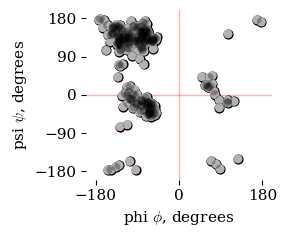

In [93]:
# stolen from https://weisscharlesj.github.io/BiopythonRamachandran/VisTop8000_COMPLETE/03Ramachandran/03Ramachandran_Plot_v8.html
# see https://biopython.org/docs/dev/api/Bio.PDB.MMCIFParser.html

# requires biopython, matplotlib

import Bio.PDB
from Bio.PDB.vectors import calc_dihedral, calc_angle

import matplotlib.pyplot as plt
%matplotlib inline
import os

import warnings
from Bio import BiopythonWarning
warnings.simplefilter('ignore', BiopythonWarning)
def ramachandran(PDB):
    """Accepts a PDB file name (string) and returns two lists of phi 
    and psi angles, respectively.
    """
    parser = Bio.PDB.MMCIFParser()
    structure = parser.get_structure('protein', PDB)
    polypeptide = Bio.PDB.PPBuilder().build_peptides(structure[0])
    
    phi = []
    psi = []

    for strand in polypeptide:
        print(f"Processing strand: {strand}")
        phipsi = strand.get_phi_psi_list()
        for point in phipsi:
            try:
                phi_point = point[0] * (180 / 3.14159)
                psi_point = point[1] * (180 / 3.14159)
                phi.append(phi_point)
                psi.append(psi_point)
            except TypeError:            # this error occurs when phi or psi is None, which happens for the first and last residues of each strand
                pass
    
    return phi, psi

phi, psi = ramachandran('data/2PTN.cif')
fig, ax = plt.subplots(figsize=(3,2.5))  

s=40
ax.scatter(phi, psi, marker='o', s=s, facecolor='red', edgecolors='black', alpha=1  )
ax.scatter(phi, psi, marker='o', s=s, facecolor='white', edgecolors='none', alpha=1  )
ax.scatter(phi, psi, marker='o', s=s, facecolor='black', edgecolors='none', alpha=0.3  )

limit = 200
ax.set(xlim=(-limit, limit), ylim=(-limit, limit),
       xticks=[-180,  0, 180], yticks=[-180, -90, 0, 90, 180],
       xlabel=r'phi $\phi$, degrees', ylabel=r'psi $\psi$, degrees')

ax.axvline(x=0, color='red', lw=1, ls='-', alpha = 0.3, zorder=-1)
ax.axhline(y=0, color='red', lw=1, ls='-', alpha = 0.3, zorder=-1)

# add padding around axes
plt.savefig('images/trypsin_ramachandran.pdf', bbox_inches='tight', pad_inches=0.1)
plt.savefig('images/trypsin_ramachandran.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Interpretation

Visualization of data allows for effective interpretation. Here we see that the pairs of $\phi$ and $\psi$ tortional angles cluster in two main regions. We will see later in the course that these represent the famous secondary structures: $\alpha$-helices and $\beta$-sheets. 
